In [176]:
# 1. Load Dataset [csv]
# 2. Eng Sentences -> Embeddings
# 2.1 : What is the capital of the France ?
# 2.2 : we convert the words of this sentence into numerical indices
# => VOCAB : of unique words with indices
# => so our sentence could be something like [1, 2, 5, 7, 8, 4, 10]
# => pass to Embedding Model : and this produces vector (for our case it is 50 dim) for each of these numbers
# 3. RNN Arch.
# 4. Training
# 5. Prediction

In [177]:
# Load
import pandas as pd
df = pd.read_csv('100_Unique_QA_Dataset.csv')

In [178]:
df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


In [179]:
# TOKENIZE
def tokenize(text):
  # PREPROCESSING
  text = text.lower()
  text = text.replace('?', '')
  text = text.replace("'", "")

  return text.split()

In [180]:
tokenize('What is the captial of France?')

['what', 'is', 'the', 'captial', 'of', 'france']

In [181]:
# VOCAB FORMATION
vocab = {'<UNK>':0}

def build_vocab(row):
  print(row['question'], row['answer'])
  tokenized_question = tokenize(row['question'])
  tokenized_answer = tokenize(row['answer'])

  merged_tokens = tokenized_question + tokenized_answer

  for token in merged_tokens:
    if token not in vocab:
      vocab[token] = len(vocab)

In [182]:
df.apply(build_vocab, axis=1)

What is the capital of France? Paris
What is the capital of Germany? Berlin
Who wrote 'To Kill a Mockingbird'? Harper-Lee
What is the largest planet in our solar system? Jupiter
What is the boiling point of water in Celsius? 100
Who painted the Mona Lisa? Leonardo-da-Vinci
What is the square root of 64? 8
What is the chemical symbol for gold? Au
Which year did World War II end? 1945
What is the longest river in the world? Nile
What is the capital of Japan? Tokyo
Who developed the theory of relativity? Albert-Einstein
What is the freezing point of water in Fahrenheit? 32
Which planet is known as the Red Planet? Mars
Who is the author of '1984'? George-Orwell
What is the currency of the United Kingdom? Pound
What is the capital of India? Delhi
Who discovered gravity? Newton
How many continents are there on Earth? 7
Which gas do plants use for photosynthesis? CO2
What is the smallest prime number? 2
Who invented the telephone? Alexander-Graham-Bell
What is the capital of Australia? Canber

,0
0,None
1,None
2,None
3,None
4,None
...,...
85,None
86,None
87,None
88,None


In [183]:
len(vocab)

324

In [184]:
# WORDS TO INDICES
def text_to_indices(text, vocab):
  indexed_text = []

  for token in tokenize(text):

    if token in vocab:
      indexed_text.append(vocab[token])
    else:
      indexed_text.append(vocab['<UNK>'])

  return indexed_text

In [185]:
text_to_indices('What is the captial of France?', vocab)

[1, 2, 3, 0, 5, 6]

In [186]:
text_to_indices('What is spacex', vocab)

[1, 2, 0]

In [187]:
# Now we will use our dataset, pick row each question and answer and convert that in these indices
# we will take help of dataloader and dataset classes

import torch
from torch.utils.data import Dataset, DataLoader


In [188]:
class QADataset(Dataset):

  def __init__(self, df, vocab):
    self.df = df
    self.vocab = vocab

  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, index):

    numerical_question = text_to_indices(self.df.iloc[index]['question'], self.vocab)
    numerical_answer = text_to_indices(self.df.iloc[index]['answer'], self.vocab)

    return torch.tensor(numerical_question), torch.tensor(numerical_answer)

In [189]:
# Create an Obj
dataset = QADataset(df, vocab)

In [190]:
# First Question and Answer in Numerical Indices
dataset[0]

(tensor([1, 2, 3, 4, 5, 6]), tensor([7]))

In [191]:
# Dataloder object
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
# since dataset is very small we kept batch_size=1
# No need of padding, because we need padding in case of more batch_size and they(textual data) have different shape/size

In [192]:
for question, answer in dataloader:
  print(question, answer)

# this answer of dataloader is 2d tensor([[285]]) which will cause problem
# It should be 1d

tensor([[ 10,  96,   3, 104, 239]]) tensor([[240]])
tensor([[ 10, 308,   3, 309, 310]]) tensor([[311]])
tensor([[ 42, 137,   2, 226,  12,   3, 227, 228]]) tensor([[155]])
tensor([[  1,   2,   3, 141, 117,  83,   3, 277, 278]]) tensor([[121]])
tensor([[  1,   2,   3,  37,  38,  39, 161]]) tensor([[162]])
tensor([[  1,  87, 229, 230, 231, 232]]) tensor([[233]])
tensor([[ 1,  2,  3, 92, 93, 94]]) tensor([[95]])
tensor([[ 42, 318,   2,  62,  63,   3, 319,   5, 320]]) tensor([[321]])
tensor([[  1,   2,   3, 221,   5, 222, 223, 224]]) tensor([[225]])
tensor([[ 10,  75,   3, 296,  19, 297]]) tensor([[298]])
tensor([[  1,   2,   3,  33,  34,   5, 245]]) tensor([[246]])
tensor([[1, 2, 3, 4, 5, 8]]) tensor([[9]])
tensor([[10,  2,  3, 66,  5, 67]]) tensor([[68]])
tensor([[ 10, 140,   3, 141, 142,  12, 143,  83,   3, 144]]) tensor([[145]])
tensor([[ 42, 263, 264,  14, 265, 266, 158, 267]]) tensor([[268]])
tensor([[  1,   2,   3,   4,   5, 286]]) tensor([[287]])
tensor([[ 10,  11, 189, 158, 190]]) 

RNN Architecture
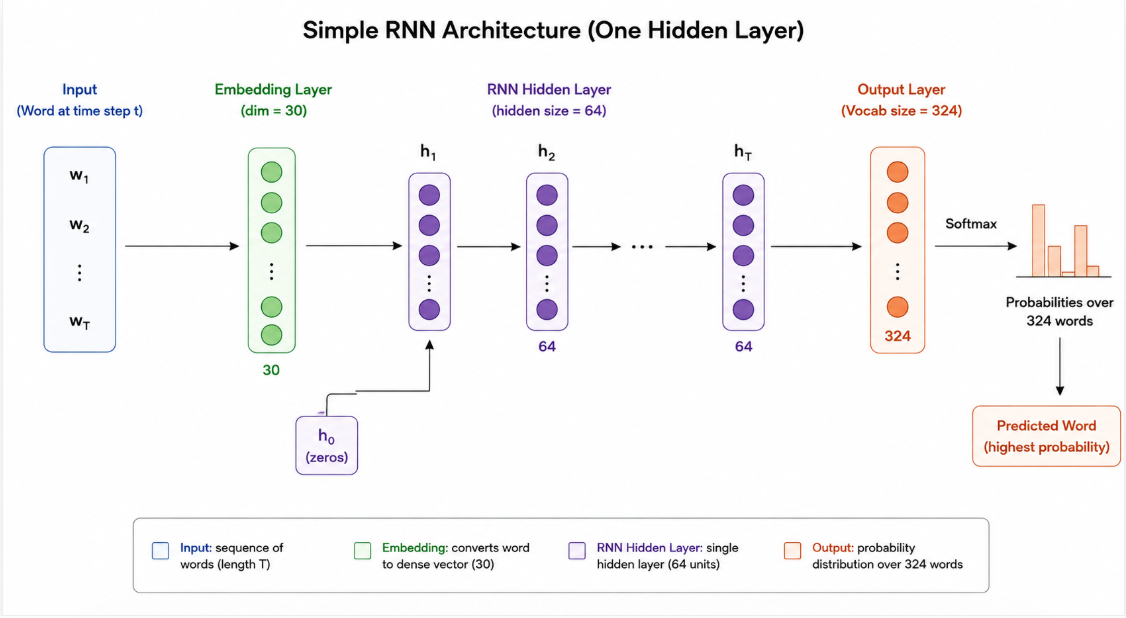

In [193]:
# Multiclass Classification
# Since our embedding is going to be 50 dimensional
# so input layer have 50 neurons
# hidden is our decision choice 64 here
# 324 is number of words in our vocab so output layer will hold one neuron of 324 with maximum probability as output/prediction

In [194]:
import torch.nn as nn

In [195]:
class SimpleRNN(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()

    # Arch [here fc : fully connected layer/ouput layer]
    self.embedding = nn.Embedding(vocab_size, embedding_dim=50)
    self.rnn = nn.RNN(50, 64, batch_first=True)
    self.fc = nn.Linear(64, vocab_size)

  def forward(self, question):
    embedded_questioin = self.embedding(question)
    hidden, final = self.rnn(embedded_questioin)
    output = self.fc(final.squeeze(0))
    return output

In [196]:
# see what's happening
dataset[0][0]

tensor([1, 2, 3, 4, 5, 6])

In [197]:
x = nn.Embedding(324, embedding_dim=50)

In [198]:
x(dataset[0][0]).shape
# a tensor [so here we are getting 6 vectors of dim 50]
# this embedding layer converting each word into 50 dim vector
# 0 means 1st question and number of words are 6

torch.Size([6, 50])

In [199]:
a = x(dataset[0][0])
# a is set of vectors and which is output of x

In [200]:
# second layer
y = nn.RNN(50, 64, batch_first=True)

In [201]:
# we will send a in y
y(a)

(tensor([[ 0.1862,  0.5472, -0.1409,  0.3604,  0.3924, -0.4528,  0.6855, -0.0709,
          -0.7138, -0.0550,  0.4469, -0.1881, -0.5192, -0.3441,  0.0124, -0.8688,
           0.0020,  0.1661, -0.2639,  0.7100, -0.5926,  0.7337, -0.0081,  0.2315,
          -0.1401,  0.0960, -0.7352,  0.5827,  0.1144,  0.4588,  0.6441, -0.1277,
           0.4415, -0.6123,  0.3245, -0.4310, -0.0419,  0.1647,  0.1897, -0.1341,
           0.4722, -0.3157, -0.3002,  0.4853, -0.5176, -0.0538, -0.1563, -0.3829,
           0.5061, -0.3596, -0.1299, -0.8021,  0.2569, -0.0660, -0.6616,  0.1064,
          -0.1463,  0.3823, -0.2192,  0.2772,  0.6324,  0.4853, -0.4178,  0.3117],
         [-0.3823,  0.0452, -0.1597,  0.3204,  0.3270, -0.2536, -0.5673, -0.1641,
           0.3046, -0.4328, -0.1826, -0.2881,  0.5600, -0.7350,  0.2583,  0.3755,
          -0.1892, -0.1471,  0.6176,  0.5057,  0.2022, -0.3252,  0.6722, -0.2481,
           0.1573, -0.0075, -0.8462, -0.1752, -0.2753,  0.7832, -0.7811, -0.4342,
           0.41

In [202]:
# we get a tuple, we get 2d tensor and one more tensor
# first item of tupel is tensor and it's shape

# hidden state
y(a)[0].shape

torch.Size([6, 64])

In [203]:
# final output
y(a)[1].shape

torch.Size([1, 64])

In [204]:
# what's going on
# so technically we have one tensor and we are sending a sentence in it [1, 2,3, 4,5, 6] words
# and each word or this sentence is going one by one
# so when we send first we get o1 [output1] then o2 and so on
#  so this 6,64 is combined output of these o1->o6
# and this last 1,64 is final output which is o6 itself [check last one]
# RNN gives two output
# That's why here we are not able to use sequential layer, as it expects one output as input of next layer
# here self.embedding one output fine, but nn.RNN giving two outputs which sequential doesnt allow [each layer output]
# that's why it will require manual(forward pass def) code as sequential not allowed

In [205]:
# let's see what's going on with fc
b = y(a)[1]

# create one layer [last]
z = nn.Linear(64, 324)

In [206]:
# sending rnn output to fc
# see, we get expected
z(b).shape

torch.Size([1, 324])

In [207]:
# imp variables
learning_rate = 0.001
epochs = 20

In [208]:
model = SimpleRNN(len(vocab))

In [209]:
# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [210]:
# Training Loop
for epoch in range(epochs):
  total_loss = 0

  for question, answer in dataloader:

    optimizer.zero_grad()

    # forward pass
    output = model(question)
    print(output.shape)
    # this output have different shape which will cause problem which is currently
    #  [1, 6, 324] while expected is [1, 324] always
    # batch_first=True added this in rnn and still it gives [1, 1, 324] due to batch
    #  so we will use squeeze to remove this extra

    # loss
    loss = criterion(output, answer[0])

    # gradients
    loss.backward()

    # update
    optimizer.step()

    total_loss = total_loss + loss.item()

  print(f"Epoch : {epoch+1}, Loss: {total_loss:4f}")

torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1, 324])
torch.Size([1

In [211]:
# predictions
def predict(model, question, threshold=0.5):

  # convert question to numbers
  numerical_question = text_to_indices(question, vocab)

  # tensor
  question_tensor = torch.tensor(numerical_question).unsqueeze(0)

  # send to model
  output = model(question_tensor)

  # convert logits to probs
  probs = torch.nn.functional.softmax(output, dim=1)

  # find index of max prob
  value, index = torch.max(probs, dim=1)

  if value < threshold:
    print("I don't know")

  print(list(vocab.keys())[index])

In [212]:
predict(model, "What is the largest planet in our solar system?")

jupiter


In [213]:
list(vocab.keys())[7]

'paris'